# Task test conditions

Each task has an out-of-distribution **test** variant (`generate(..., test=True)`)
in which the dynamics change partway through the trial (at the midpoint, dashed
line). Here we show a normal **training** example next to a **test** example for
every task:

- **drift** — the drift direction reverses (right -> left).
- **binary noise** — the Bernoulli probability jumps to `test_prob`.
- **gaussian process** — the spatial and temporal frequencies double.
- **bifurcate** — after the ones meet, the zeros return **double-fast from a single
  end** (one-sided), instead of symmetrically from the middle or the ends.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from tasks import BinaryNoiseTask, DriftTask, GaussianProcessTask, BifurcateTask

VECTOR_LENGTH = 20
NUM_STEPS     = 100
SEED          = 0


def plot_train_test(make_task, title, switch_line=True):
    train = make_task().generate(NUM_STEPS, seed=SEED)
    test  = make_task().generate(NUM_STEPS, seed=SEED, test=True)
    fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
    for ax, data, lab in [(axes[0], train, 'training'), (axes[1], test, 'test')]:
        im = ax.imshow(data.T, aspect='auto', cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
        ax.set_ylabel(lab + ' element')
        if switch_line:
            ax.axvline(NUM_STEPS // 2 - 0.5, color='w', lw=1.6, ls='--')
            ax.axvline(NUM_STEPS // 2 - 0.5, color='k', lw=0.6, ls='--')
        fig.colorbar(im, ax=ax)
    axes[1].set_xlabel('timestep')
    axes[0].set_title(f'{title}  (training vs. test)')
    plt.tight_layout()
    plt.show()

## Drift — direction reverses at the midpoint

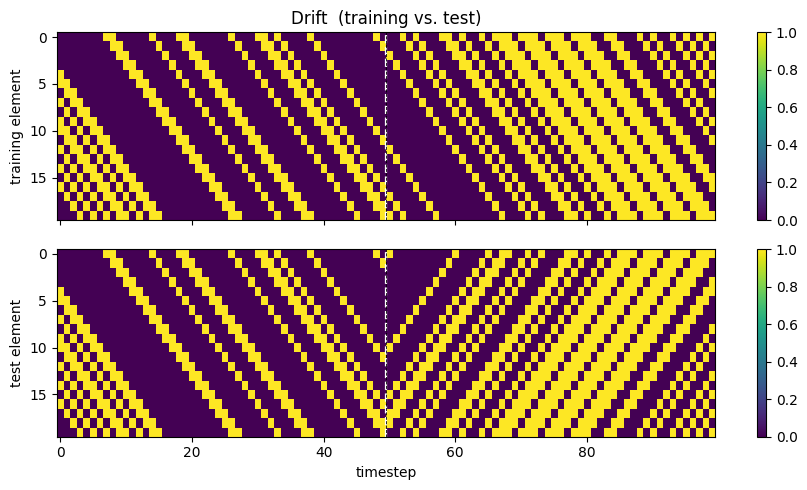

In [2]:
plot_train_test(lambda: DriftTask(vector_length=VECTOR_LENGTH, prob=0.3), 'Drift')

## Binary noise — Bernoulli probability jumps at the midpoint

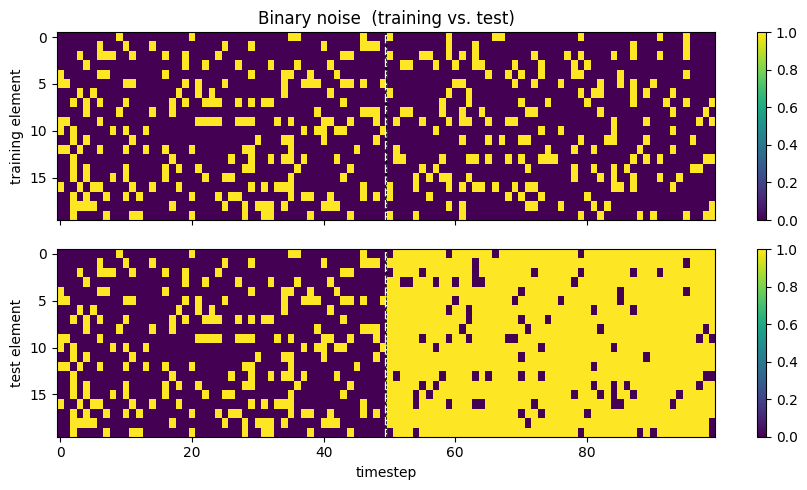

In [3]:
plot_train_test(lambda: BinaryNoiseTask(vector_length=VECTOR_LENGTH, prob=0.2, resample_prob=1.0, test_prob=0.9), 'Binary noise')

## Gaussian process — spatial & temporal frequency double at the midpoint

/Users/nicholaswatters/Desktop/grad_school/research/exploration_policies/toy_v1/tasks/../tasks/gaussian_process.py:81: RuntimeWarning: divide by zero encountered in matmul
  mean = weights @ self._history
/Users/nicholaswatters/Desktop/grad_school/research/exploration_policies/toy_v1/tasks/../tasks/gaussian_process.py:81: RuntimeWarning: overflow encountered in matmul
  mean = weights @ self._history
/Users/nicholaswatters/Desktop/grad_school/research/exploration_policies/toy_v1/tasks/../tasks/gaussian_process.py:81: RuntimeWarning: invalid value encountered in matmul
  mean = weights @ self._history


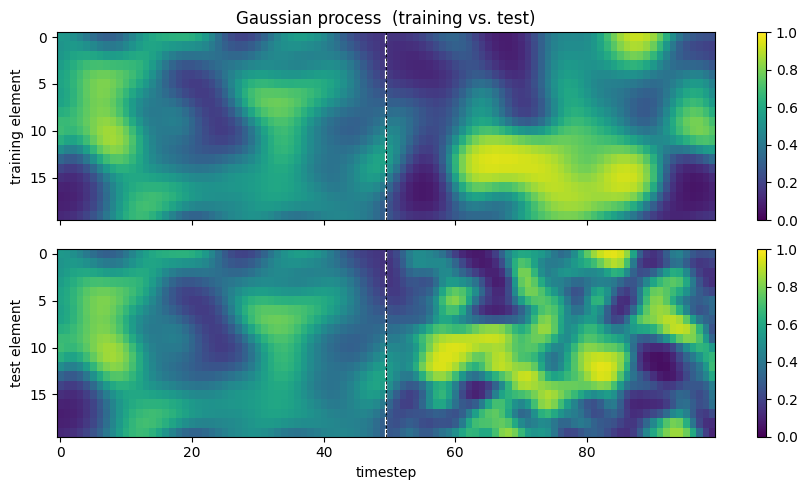

In [4]:
plot_train_test(lambda: GaussianProcessTask(vector_length=VECTOR_LENGTH, spatial_temperature=3.0, temporal_temperature=5.0), 'Gaussian process')

## Bifurcate — in test, zeros return double-fast from one end (after the midpoint)

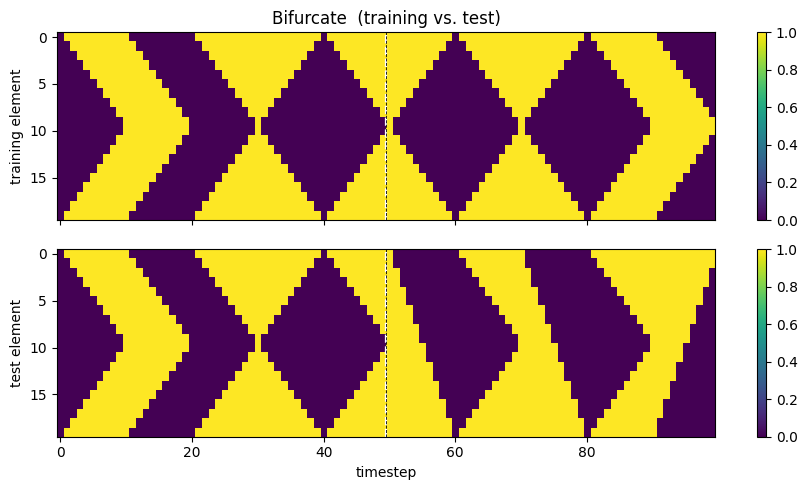

In [5]:
plot_train_test(lambda: BifurcateTask(vector_length=VECTOR_LENGTH), 'Bifurcate')